#########################Projet Titanic#############################

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from mon_outillage import asymetrique_symetrique
from mon_outillage import pretraitement_data
from mon_outillage import verifier_outlier
from mon_outillage import cleaner_outlier
from mon_outillage import pipeline_nettoyage_modele
from mon_outillage import  evaluer_classification
from mon_outillage import valider_stabilite
from mon_outillage import compare_modele
import warnings
warnings.filterwarnings('ignore')

##Chargement des fichiers et premiers visualisations des fichiers

In [2]:
df_train = pd.read_csv("C:/Users/PC/Documents/titan/train.csv")
df_train.shape

(891, 12)

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#Avant traitement
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
print(pretraitement_data(df_train))


colonnes supprimer (>60%) de vides : ['Cabin']
 -Age : Moyenne utilise (skew : 0.39)
  -Embarked : mode utilise
pretraitement terminer avec succes!!!
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4       

In [7]:
df_clean = pretraitement_data(df_train)
df_clean.isnull().sum().max()

colonnes supprimer (>60%) de vides : ['Cabin']
 -Age : Moyenne utilise (skew : 0.39)
  -Embarked : mode utilise
pretraitement terminer avec succes!!!


np.int64(0)

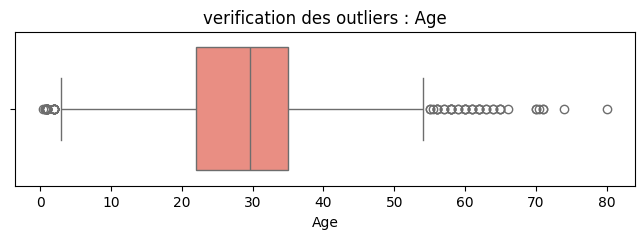

In [8]:
#verifier les outliers
verifier_outlier(df_clean, 'Age')

In [9]:
df_clean.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


############# Analyse Explorative des Donnees ##########################################

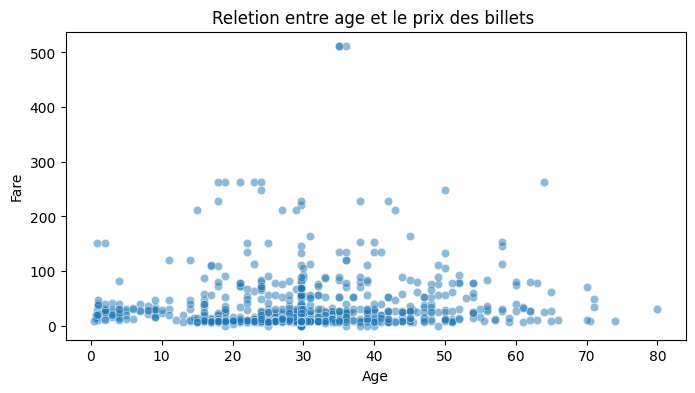

In [10]:
#Analyse bivariés
#je vais voir l'age et le fare
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_clean, x= 'Age', y ='Fare', alpha = 0.5)
plt.title("Reletion entre age et le prix des billets ")
plt.show()

#conclusion de la relation entre l'age et le prix des billets(fare)
On voit une densite maximale des prix entre 0 et 100 
donc ici on peut dire que la majorite des passagers
achete des billets de moins de 100 dollars.
Tandisque les prix elevees sont des outliers

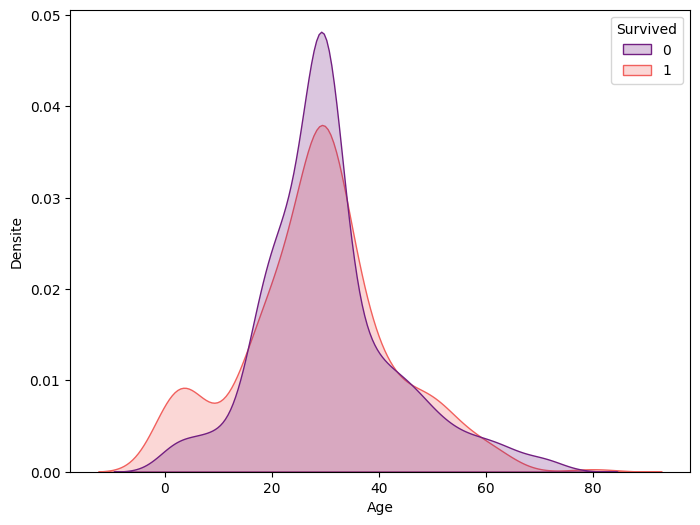

In [11]:
#Analyser l'age et la survie
plt.figure(figsize=(8,6))
sns.kdeplot(data=df_clean, x ='Age', hue= 'Survived', fill=True, palette='magma', common_norm=False)
plt.xlabel("Age")
plt.ylabel("Densite")
plt.show()

Conclusion: le KDE plot releve que l'age est un facteur determinant pour les deux extremes.
entre 0 et 12 ans, on voit que les personnes moins agees survivent, entre 18 et 35 ans les adultes portent le poids lourd des non survivants.
Et enfin, les personnnes qui ont plus de 70 ans leur densite de survie est infiniment minime.

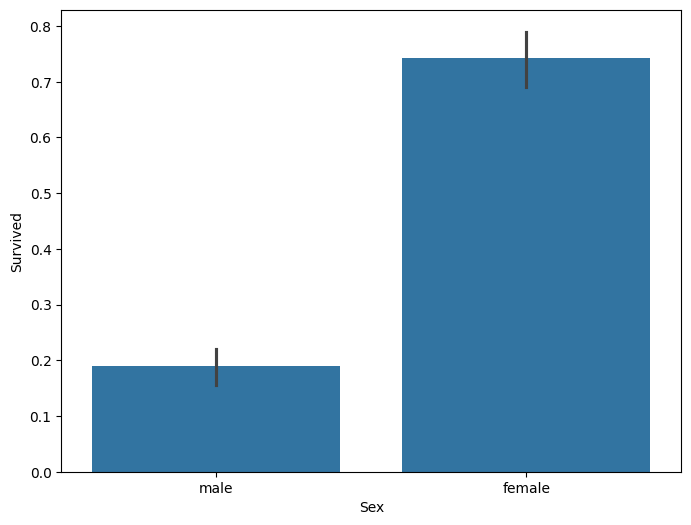

In [12]:
#entre le sexe et l'age
plt.figure(figsize=(8, 6))
sns.barplot(data= df_clean, x='Sex', y='Survived')
plt.show()

Conclusion:On peut en deduire que pres de 75% des femmes ont survecu au nauffrage,
alorsque pour les hommmes il en est de 20%. 

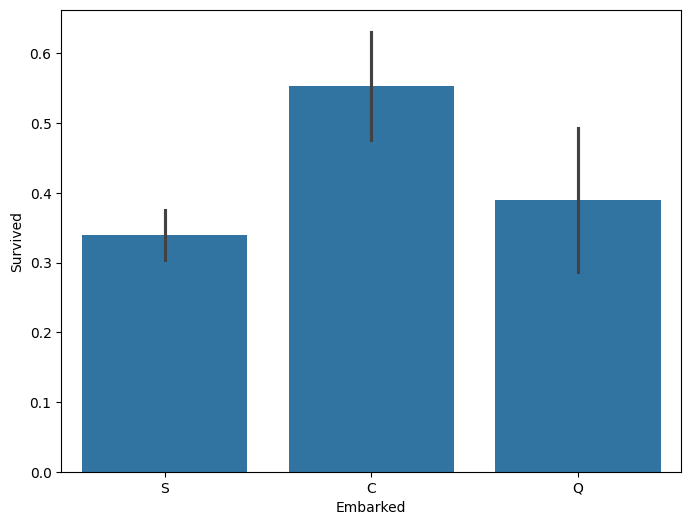

In [13]:
#Entre survived et le port d'embarque
plt.figure(figsize=(8, 6))
sns.barplot(data=df_clean, x='Embarked', y ='Survived')
plt.show()

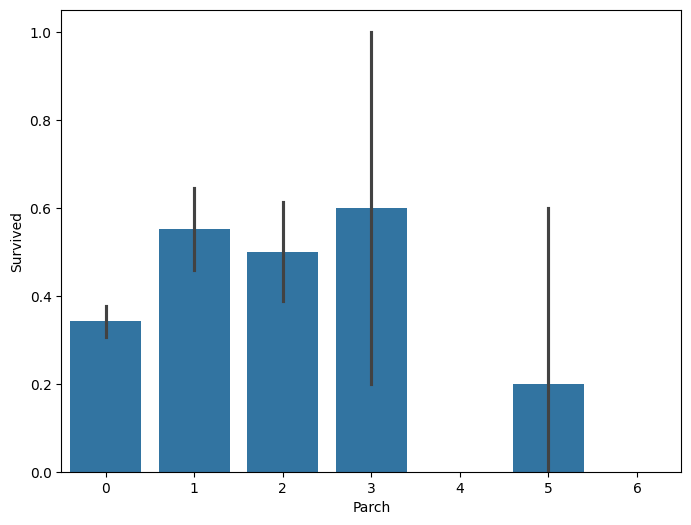

In [14]:
#entre parch et survived
plt.figure(figsize=(8, 6))
sns.barplot(data=df_clean, x ='Parch', y='Survived')
plt.show()

Conclusion : on voit que voyager seule parch(0) etait un handicap avec un taux de survie de 34 %,
alors que parch(1, 2, 3) ça veut dire en petit famille etait mieux avec presque 59 % de survie.
voyager en grande famille c'etait la pire avec taux de survie de 20 %

### Analyses  multivariées  

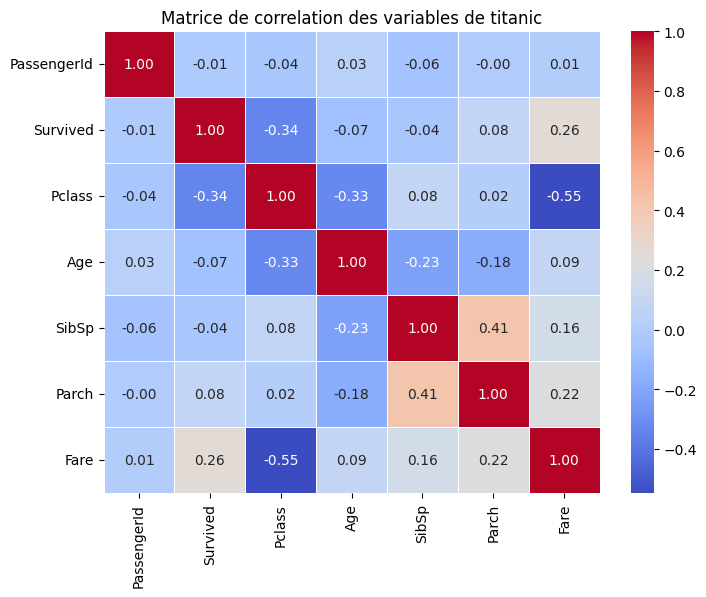

In [15]:
#calcule la correlation
#on filtre les colonnes numeriques
df_numeric = df_clean.select_dtypes(include=['number'])
cor = df_numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de correlation des variables de titanic")
plt.show()

Conclusion: Le heatmap de correlation confirme les graphiques precedent, on peut dire que plus l'age est grand plus le taux de survie est faible ce qui explique la correlation negative(-0.07).
La correlation entre Pclass et survived est aussi negative -0.34, cela explique plus que le nombre de classe est grand(3) plus le survie est faible , donc dans ce cas on peut dire les passagers du premier class ont un avantage de survie par rapport aux autres.


#########  Nettoyage et Feature Engineering #######

In [16]:
#Creer une nouvelle variables pour fusionner parch et sibsp
df_clean['family'] = df_clean['Parch'] + df_clean['SibSp'] + 1
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [17]:
#suppression des colonnes inutiles
col_sup = ['Ticket', 'Parch', 'Name','SibSp']
df_clean = df_clean.drop(columns=col_sup)
df_clean.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,family
0,1,0,3,male,22.0,7.2500,S,2
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,1


                ######## Préparation des données pour la modélisation ###########

In [18]:
#Separation des features /cible
#isole l'id
test_id = df_clean['PassengerId']
#Gerer X sans la cible et l'id 
X = df_clean.drop(columns=['Survived', 'PassengerId'])

#isoler la cible 
y= df_clean['Survived']

In [19]:
import joblib
from sklearn.model_selection import train_test_split
from mon_outillage import compare_modele

col_risq = ['Age', 'Fare']
for col in col_risq:
    df_clean = cleaner_outlier(df_clean, col)
print("les outliers geres avec succes!!")

#Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#definir le pipeline nettoyage
nettoyage = pipeline_nettoyage_modele(X_train)

#comparaison 
tableau = compare_modele(X_train, X_test, y_train, y_test, nettoyage)
print(tableau)

#on applique la fonction pipeline
modele = pipeline_nettoyage_modele(X_train)

#Entrainement
modele.fit(X_train, y_train)

#predire

y_pred = modele.predict(X_test)

#CALCULE TA VRAIE PRÉCISION ICI :
from sklearn.metrics import accuracy_score
y_pred_class = np.round(y_pred)

accuracy = accuracy_score(y_test, y_pred_class)

print(f"--- RÉSULTAT FINAL ---")
print(f"Ma vraie précision (Accuracy) est de : {accuracy * 100:.2f}%")

print("la dimension est :", X_train.shape)



les outliers geres avec succes!!
                modele  Score R2
1        Random Forest  0.821229
3                  SVM  0.815642
0  logistic regression  0.804469
4                  KNN  0.804469
5             AdaBoost  0.804469
2    Gradient Boosting  0.798883
--- RÉSULTAT FINAL ---
Ma vraie précision (Accuracy) est de : 81.01%
la dimension est : (712, 6)


##Verifier la precision du modele

In [ ]:
from mlflow_tracker import tracker_mlflow
from sklearn.ensemble import RandomForestClassifier
from mon_outillage import pipeline_nettoyage_modele

modele, y_pred = tracker_mlflow(
    model = pipeline_nettoyage_modele(X_train),
    params = {"n_estimators":200,"max_depth":4, "random_state":42},
    X_train = X_train,
    X_test = X_test,
    y_train= y_train,
    y_test = y_test
)


2026/03/15 22:41:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:41:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.8101
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Experience 'Random_forest_v6' enregistree dans MLflow !


----Evaluation du: Random Forest----
 Precision (Accuracy) : 81.01%
F1 score :75.00%
Precision :82.26%
recall : 68.92%
------------------------------


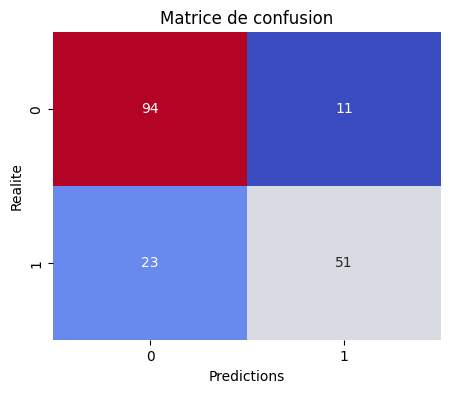

In [21]:
evaluer_classification(y_test, y_pred_class, "Random Forest")


In [22]:
#verifier la stabilite par la cross validation
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

#instancier l'object
mon_object = pipeline_nettoyage_modele(X_train)

 #Extraction manuelle depuis le pipeline de base
preprocessing = mon_object.named_steps['preprocessor']

#creation du pipeline poue le modele random forest
mike_pipe = make_pipeline(preprocessing, RandomForestClassifier(n_estimators=100, random_state=42))

score_vd = valider_stabilite(mike_pipe, X_train, y_train)

--- VALIDATION CROISÉE (5 Folds) ---
Moyenne des scores (accuracy) : 0.79%
Écart-type (instabilité)     : +/- 0.02%
le modele est stable et fiable


In [23]:
X.isnull().sum().max()

np.int64(0)

In [24]:
print(mike_pipe.named_steps.keys())

dict_keys(['columntransformer', 'randomforestclassifier'])


#- Reglages des hyperparametres

In [25]:
from mon_outillage import optimiser_modele
#je cree un dictionnaire 
grille_params_rf = {
   'randomforestclassifier__n_estimators': [100, 200],
   'randomforestclassifier__max_depth': [5, 10, None],
   'randomforestclassifier__criterion': ['gini', 'entropy']
}

#Appliquer la fonction
modele_param = optimiser_modele(mike_pipe, grille_params_rf, X_train, y_train) 

Optimisation :
Fitting 5 folds for each of 12 candidates, totalling 60 fits
meilleur parametre : {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 200}
meilleur score :83.28


Le modele random forest a ete optimise avec le gridSearchCV  avec une score de 83.28%. Avec 60 entrainements(fits) , le modele a montre sa capacite a etre bon sur different test de data. 

In [26]:
#Sauvegarder le modele
import joblib

joblib.dump(modele, "modele.pkl")

print("le fichier est sauvegarder avec succes!!")

le fichier est sauvegarder avec succes!!


Application du modele sur le fichier test.csv

In [27]:
#charger le modele
mod = joblib.load("modele.pkl")

#charger le fichier .csv
df_test = pd.read_csv("C:/Users/PC/Documents/titan/test.csv")
df_test.columns


Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [28]:
df_test['Family'] = df_test['SibSp'] + df_test['Parch'] + 1

In [29]:
#df_test_clean = pretraitement_data(df_test)
df_clean.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,family
0,1,0,3,male,22.0,7.2500,S,2
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,1


In [30]:
df_test = df_test.drop(columns=['SibSp', 'Parch'])
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,Family
0,892,3,"Kelly, Mr. James",male,34.5,330911,7.8292,NaN,Q,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,363272,7.0000,NaN,S,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,240276,9.6875,NaN,Q,1
3,895,3,"Wirz, Mr. Albert",male,27.0,315154,8.6625,NaN,S,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,3101298,12.2875,NaN,S,3


In [31]:
df_test = df_test.rename(columns={'Family':'family'})
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket', 'Fare',
       'Cabin', 'Embarked', 'family'],
      dtype='object')

In [32]:
#on separe l'id du test avant de tester
test_id = df_test['PassengerId']

df_test_prp = df_test.drop("PassengerId", axis=1)

#predire les survivants
survivant = mod.predict(df_test_prp)

#Creer un dataframe
resultat = pd.DataFrame({
    'PassengerId':test_id,
    'Survived':survivant
}).round(2)

#on dit 1 si le score est >=0.5 , 0 sinon
resultat['Survived'] = (resultat['Survived'] >= 0.5).astype(int)
print(resultat.head(10))

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


Creer le fichier submission

In [33]:
resultat.to_csv("submissions.csv", index=False)
print("le fichier sauvegarder avec succes")

le fichier sauvegarder avec succes


In [34]:
resultat.shape

(418, 2)

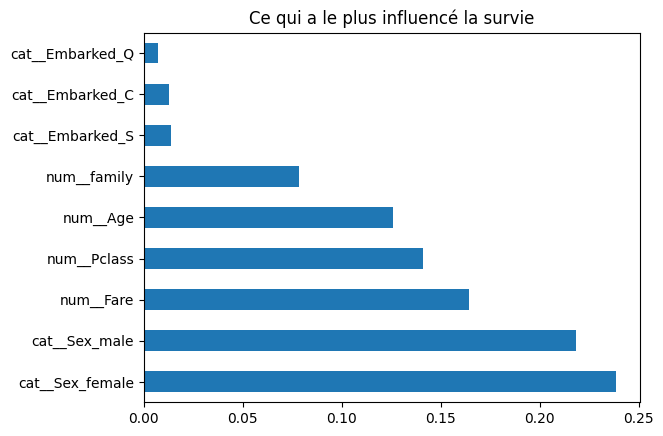

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# On récupère le modèle à l'intérieur du pipeline optimisé
rf_final = modele_param.named_steps['randomforestclassifier']

# On récupère le nom des colonnes après transformation (OneHotEncoding)
features = modele_param.named_steps['columntransformer'].get_feature_names_out()

importances = pd.Series(rf_final.feature_importances_, index=features)
importances.nlargest(10).plot(kind='barh', title="Ce qui a le plus influencé la survie")
plt.show()

##-Interpretation du modele
pour les features important, dans la figure ci-dessus on voit bien que le sexe est plus determinant pour survivre, suisvi du prix du billet et de la classe.

#Erruer
dans la matrice de confusion, le modele a predit 14 survivaient alors que c faux et aussi 18 ne survivaient alorsqu'ils survivent.
Mais dans l'ensemble le modele est tres puissant pour identifier les non survivants.

Apres avoir compare plusieurs modeles(logistic regression, svm, knm, adabost), le random forest s'est impose comme le meilleur modele dans ce jeu de donnee.
Grace à une optimisation GridSearchCV, nous avons attient les performances suivvantes:
accuracy(validation croisee):83.28%
accuracy(test final):81.12%
stabilite: le modele est juge stable et fiable avec un ecart-type faible < 5%.